In [1]:
# ==========================================
# FASE 1 - DATA CLEANING PT ANDALAS MANUFAKTUR
# ==========================================

import pandas as pd
import numpy as np

# ==========================
# LOAD DATA
# ==========================
tr_produksi = pd.read_csv("hasil.csv")

# ==========================
# CEK DATA AWAL
# ==========================
print("========== DATA AWAL ==========")
print("Ukuran Dataset :", tr_produksi.shape)

print("\nMissing Value")
print(tr_produksi.isnull().sum())

print("\nJumlah Duplikasi")
print(tr_produksi.duplicated().sum())

outlier_awal = tr_produksi[
    (tr_produksi["suhu_mesin"] < 50) |
    (tr_produksi["suhu_mesin"] > 120)
]

print("\nJumlah Outlier Suhu :", len(outlier_awal))

# ==========================
# DATA CLEANING
# ==========================

# Perbaiki tipe data
tr_produksi["tanggal"] = pd.to_datetime(tr_produksi["tanggal"])
tr_produksi["jam"] = pd.to_datetime(
    tr_produksi["jam"],
    format="%H:%M:%S"
).dt.time

# Missing Value
tr_produksi["suhu_mesin"] = tr_produksi["suhu_mesin"].fillna(
    tr_produksi["suhu_mesin"].mean()
)

# Hapus Duplikasi
tr_produksi = tr_produksi.drop_duplicates()

# Hapus Outlier Suhu
tr_produksi = tr_produksi[
    (tr_produksi["suhu_mesin"] >= 50) &
    (tr_produksi["suhu_mesin"] <= 120)
]

# ==========================
# HASIL CLEANING
# ==========================
print("\n========== HASIL CLEANING ==========")
print("Ukuran Dataset :", tr_produksi.shape)

print("\nMissing Value")
print(tr_produksi.isnull().sum())

print("\nJumlah Duplikasi")
print(tr_produksi.duplicated().sum())

outlier_akhir = tr_produksi[
    (tr_produksi["suhu_mesin"] < 50) |
    (tr_produksi["suhu_mesin"] > 120)
]

print("\nJumlah Outlier Suhu :", len(outlier_akhir))

# ==========================
# SIMPAN DATA BERSIH
# ==========================
tr_produksi.to_csv("produksi_clean.csv", index=False)

print("\nData berhasil dibersihkan dan disimpan sebagai 'produksi_clean.csv'")

========== DATA AWAL ==========
Ukuran Dataset : (30, 14)

Missing Value
id_produksi      0
tanggal          0
jam              0
nama_mesin       0
tipe_mesin       0
nama_operator    0
shift_grup       0
skill_level      0
jenis_bahan      0
vendor           0
setting_rpm      0
suhu_mesin       1
qty_ok           0
qty_ng           0
dtype: int64

Jumlah Duplikasi
0

Jumlah Outlier Suhu : 4

========== HASIL CLEANING ==========
Ukuran Dataset : (26, 14)

Missing Value
id_produksi      0
tanggal          0
jam              0
nama_mesin       0
tipe_mesin       0
nama_operator    0
shift_grup       0
skill_level      0
jenis_bahan      0
vendor           0
setting_rpm      0
suhu_mesin       0
qty_ok           0
qty_ng           0
dtype: int64

Jumlah Duplikasi
0

Jumlah Outlier Suhu : 0

Data berhasil dibersihkan dan disimpan sebagai 'produksi_clean.csv'


=== Reject per Mesin ===
nama_mesin
Cutting-01      49
Finishing-01    31
Press-01        77
Press-02        80
Welding-01      64
Name: qty_ng, dtype: int64


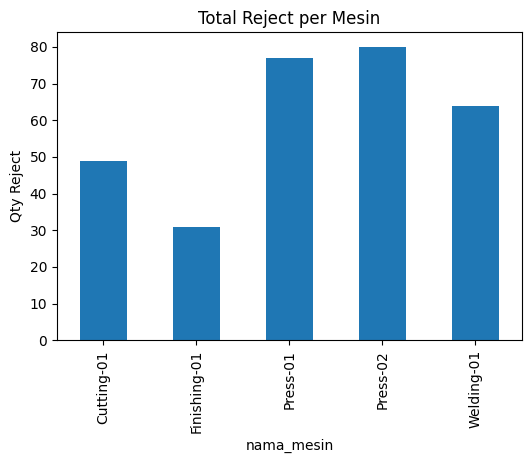


=== Reject per Shift ===
shift_grup
A    140
B     80
C     81
Name: qty_ng, dtype: int64


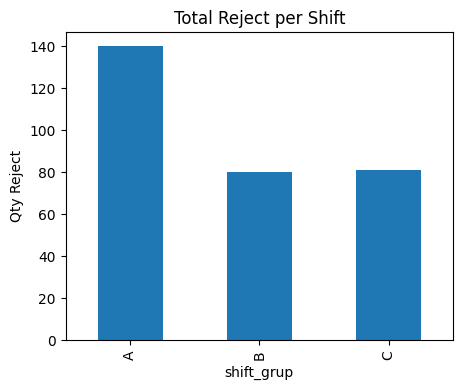


=== Reject per Skill Level ===
skill_level
1     45
2     69
4    112
5     75
Name: qty_ng, dtype: int64


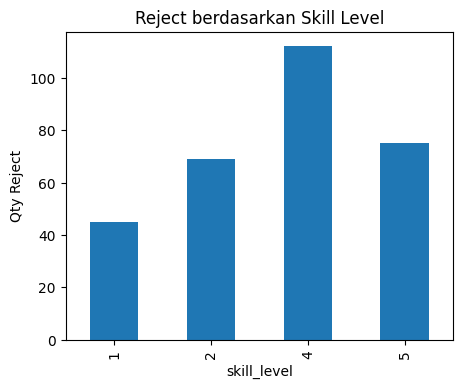

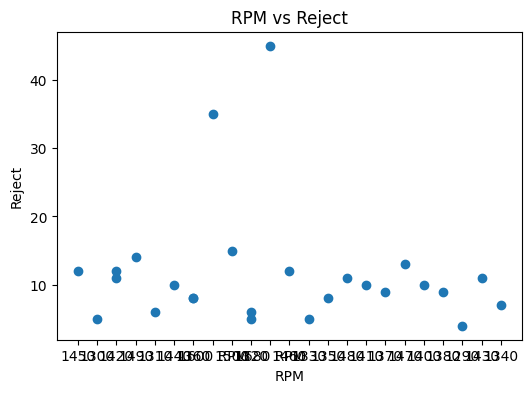

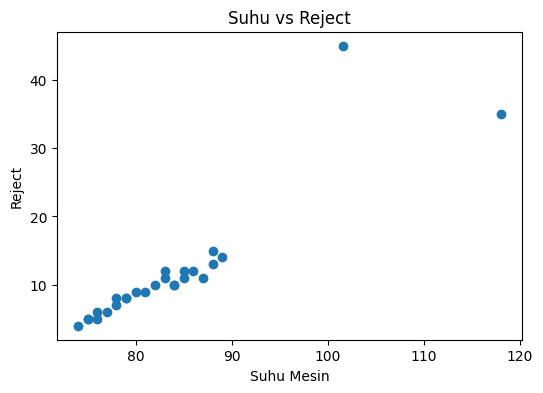

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("produksi_clean.csv")

# ==========================
# Reject per Mesin
# ==========================
reject_mesin = df.groupby("nama_mesin")["qty_ng"].sum()

print("=== Reject per Mesin ===")
print(reject_mesin)

plt.figure(figsize=(6,4))
reject_mesin.plot(kind="bar")
plt.title("Total Reject per Mesin")
plt.ylabel("Qty Reject")
plt.show()

# ==========================
# Reject per Shift
# ==========================
reject_shift = df.groupby("shift_grup")["qty_ng"].sum()

print("\n=== Reject per Shift ===")
print(reject_shift)

plt.figure(figsize=(5,4))
reject_shift.plot(kind="bar")
plt.title("Total Reject per Shift")
plt.ylabel("Qty Reject")
plt.show()

# ==========================
# Reject per Skill Level
# ==========================
reject_skill = df.groupby("skill_level")["qty_ng"].sum()

print("\n=== Reject per Skill Level ===")
print(reject_skill)

plt.figure(figsize=(5,4))
reject_skill.plot(kind="bar")
plt.title("Reject berdasarkan Skill Level")
plt.ylabel("Qty Reject")
plt.show()

# ==========================
# RPM vs Reject
# ==========================
plt.figure(figsize=(6,4))
plt.scatter(df["setting_rpm"], df["qty_ng"])
plt.xlabel("RPM")
plt.ylabel("Reject")
plt.title("RPM vs Reject")
plt.show()

# ==========================
# Suhu vs Reject
# ==========================
plt.figure(figsize=(6,4))
plt.scatter(df["suhu_mesin"], df["qty_ng"])
plt.xlabel("Suhu Mesin")
plt.ylabel("Reject")
plt.title("Suhu vs Reject")
plt.show()

nama_mesin
Cutting-01       115
Finishing-01      55
Press-01          85
Press-02        1280
Welding-01       165
Name: downtime_menit, dtype: int64


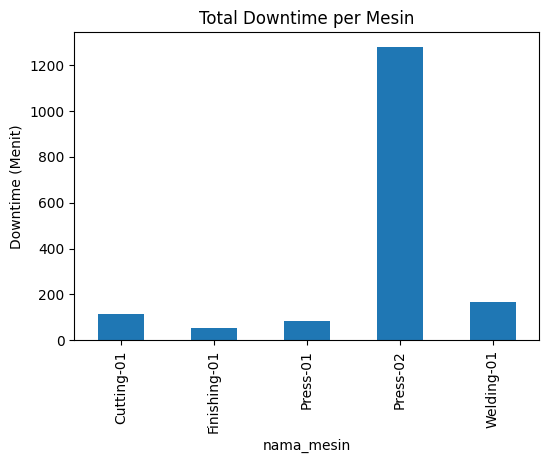

nama_mesin
Cutting-01       3700000.0
Finishing-01     1950000.0
Press-01         2300000.0
Press-02        31100000.0
Welding-01       4700000.0
Name: biaya_perbaikan, dtype: float64


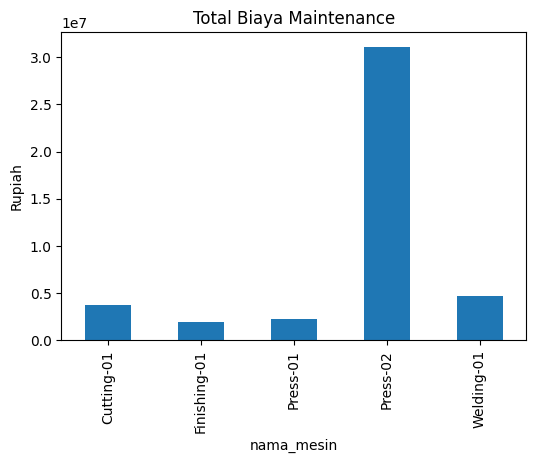

tipe_kerusakan
Sensor Error          2
Bearing Aus           2
Overheating           2
Motor Failure         2
Belt Putus            2
Roller Aus            2
Hydraulic Leak        1
Welding Head Rusak    1
Kabel Terbakar        1
Name: count, dtype: int64


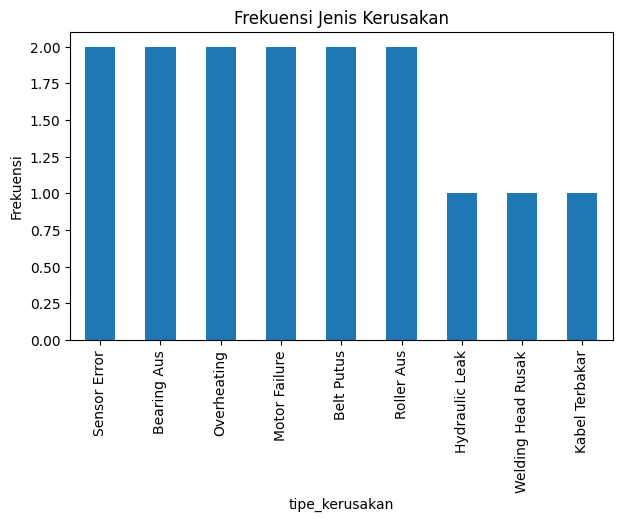

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

maintenance = pd.read_csv("maintenance.csv")

# Downtime per mesin
downtime = maintenance.groupby("nama_mesin")["downtime_menit"].sum()

print(downtime)

plt.figure(figsize=(6,4))
downtime.plot(kind="bar")
plt.title("Total Downtime per Mesin")
plt.ylabel("Downtime (Menit)")
plt.show()

# Biaya maintenance
biaya = maintenance.groupby("nama_mesin")["biaya_perbaikan"].sum()

print(biaya)

plt.figure(figsize=(6,4))
biaya.plot(kind="bar")
plt.title("Total Biaya Maintenance")
plt.ylabel("Rupiah")
plt.show()

# Jenis kerusakan
kerusakan = maintenance["tipe_kerusakan"].value_counts()

print(kerusakan)

plt.figure(figsize=(7,4))
kerusakan.plot(kind="bar")
plt.title("Frekuensi Jenis Kerusakan")
plt.ylabel("Frekuensi")
plt.show()

In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# =========================
# LOAD DATA
# =========================
df = pd.read_csv("produksi_clean.csv")

# =========================
# CLEANING SETTING RPM
# =========================
df["setting_rpm"] = (
    df["setting_rpm"]
    .astype(str)
    .str.replace(" RPM", "", regex=False)
    .str.strip()
)

df["setting_rpm"] = pd.to_numeric(df["setting_rpm"], errors="coerce")

# Hapus data yang gagal dikonversi
df = df.dropna(subset=["setting_rpm"])

# Pastikan bertipe numerik
df["setting_rpm"] = df["setting_rpm"].astype(int)

# =========================
# CLEANING SHIFT
# =========================
df["shift_grup"] = df["shift_grup"].map({
    "A": 1,
    "B": 2,
    "C": 3
})

# =========================
# MEMBUAT TARGET
# Reject Tinggi = 1
# Reject Rendah = 0
# =========================
median_reject = df["qty_ng"].median()

df["reject_tinggi"] = (df["qty_ng"] > median_reject).astype(int)

# =========================
# FITUR & TARGET
# =========================
X = df[[
    "setting_rpm",
    "suhu_mesin",
    "skill_level",
    "shift_grup"
]]

y = df["reject_tinggi"]

# =========================
# SPLIT DATA
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

# =========================
# MODEL DECISION TREE
# =========================
model = DecisionTreeClassifier(
    criterion="gini",
    random_state=42,
    max_depth=3
)

model.fit(X_train, y_train)

# =========================
# PREDIKSI
# =========================
y_pred = model.predict(X_test)

# =========================
# HASIL
# =========================
print("========== HASIL MACHINE LEARNING ==========")
print(f"Akurasi : {accuracy_score(y_test, y_pred):.2%}")

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

print("\nData yang digunakan :", len(df))
print("Data Training :", len(X_train))
print("Data Testing :", len(X_test))

========== HASIL MACHINE LEARNING ==========
Akurasi : 87.50%

Confusion Matrix
[[3 0]
 [1 4]]

Classification Report
              precision    recall  f1-score   support

           0       0.75      1.00      0.86         3
           1       1.00      0.80      0.89         5

    accuracy                           0.88         8
   macro avg       0.88      0.90      0.87         8
weighted avg       0.91      0.88      0.88         8


Data yang digunakan : 26
Data Training : 18
Data Testing : 8


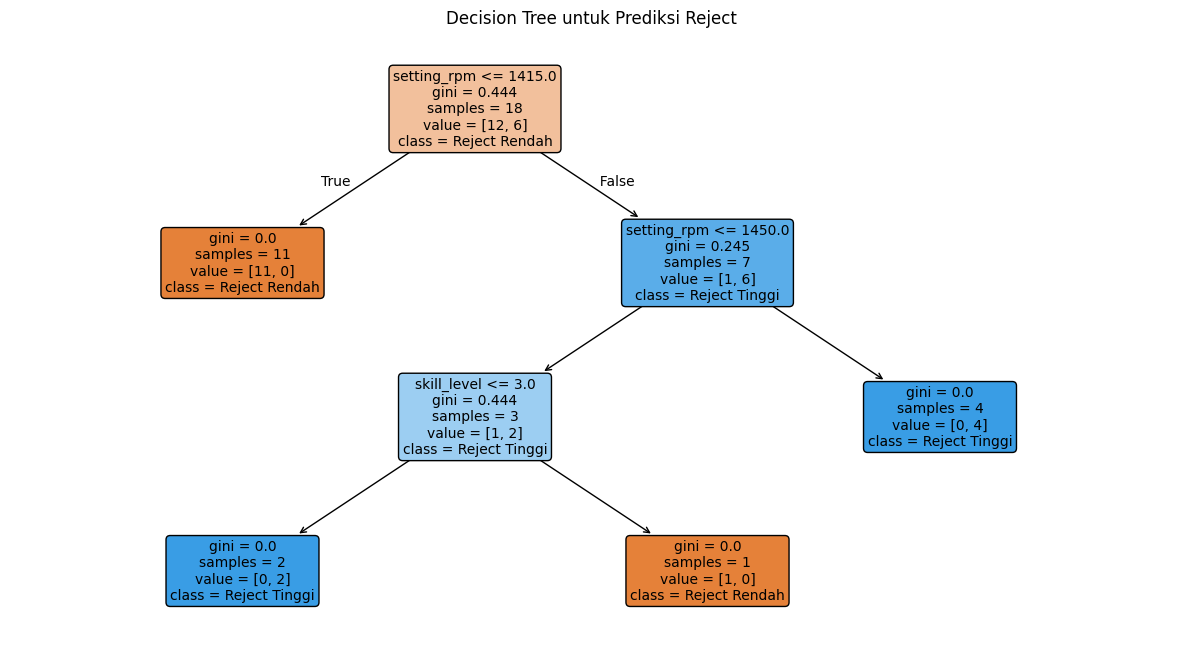

In [5]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(15,8))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Reject Rendah","Reject Tinggi"],
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title("Decision Tree untuk Prediksi Reject")
plt.show()

         Fitur  Importance
0  setting_rpm    0.833333
2  skill_level    0.166667
1   suhu_mesin    0.000000
3   shift_grup    0.000000


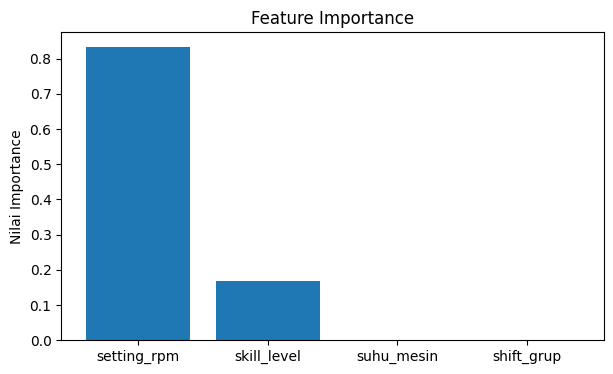

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    "Fitur": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

plt.figure(figsize=(7,4))
plt.bar(importance["Fitur"], importance["Importance"])
plt.title("Feature Importance")
plt.ylabel("Nilai Importance")
plt.show()

PT ANDALAS MANUFAKTUR - EXECUTIVE DASHBOARD
Total Output Produksi : 13786
Total Reject          : 301
Reject Rate           : 2.14%
Total Downtime        : 1700 menit
Total Biaya Maintenance : Rp 43,750,000


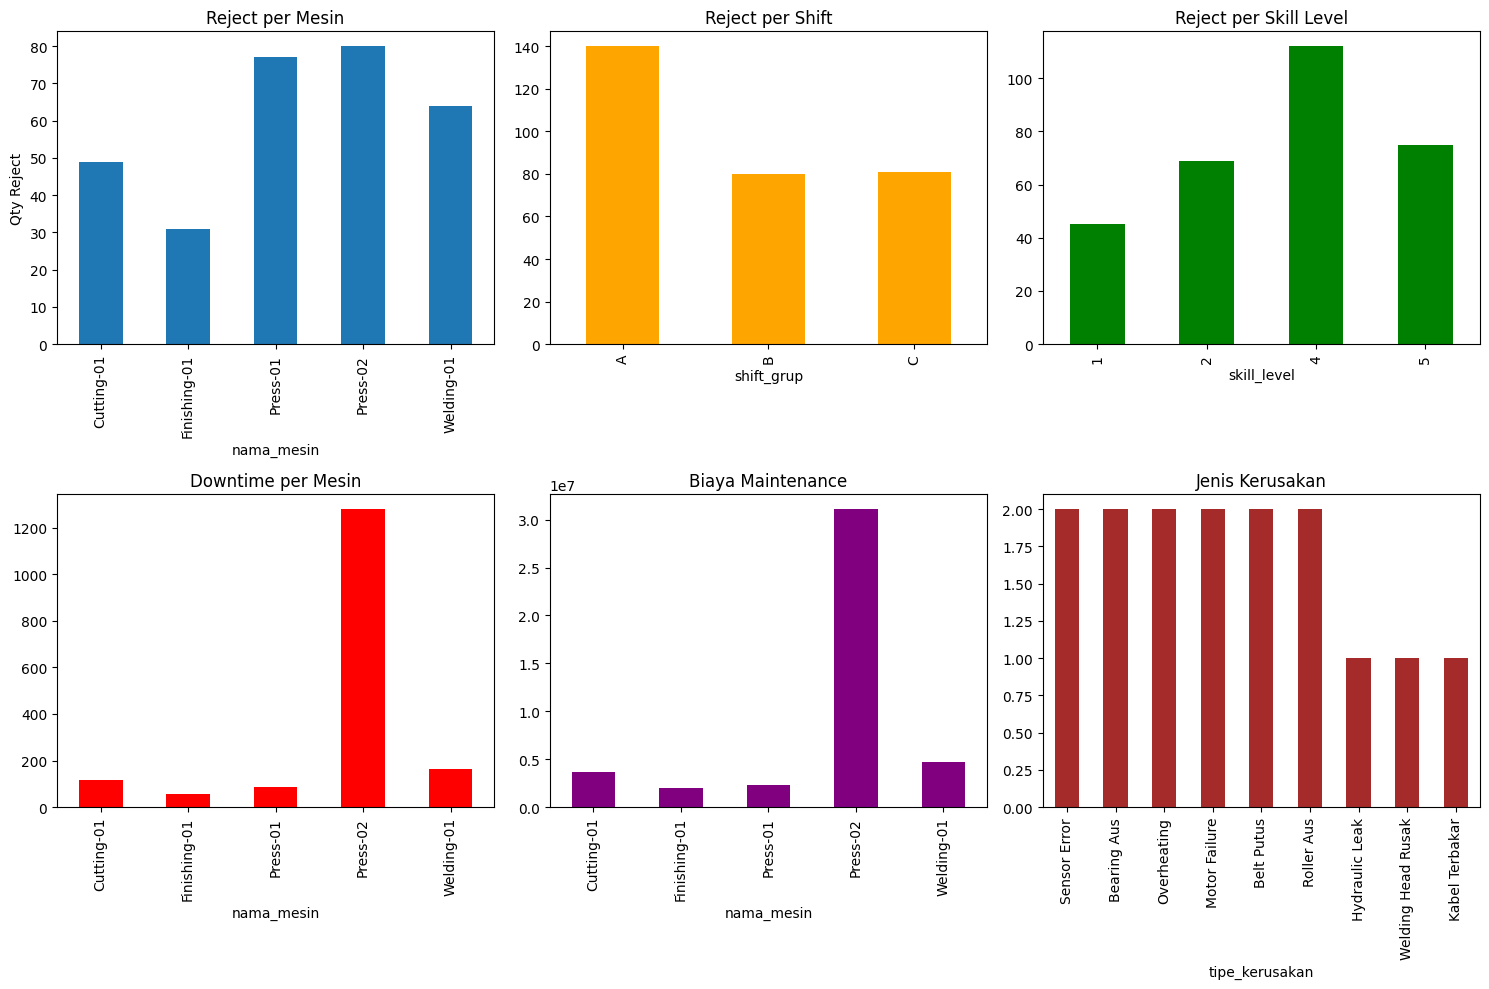

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# ==========================
# LOAD DATA
# ==========================
produksi = pd.read_csv("produksi_clean.csv")
maintenance = pd.read_csv("maintenance.csv")

# ==========================
# KPI
# ==========================
total_output = produksi["qty_ok"].sum()
total_reject = produksi["qty_ng"].sum()
reject_rate = (total_reject / (total_output + total_reject)) * 100
total_downtime = maintenance["downtime_menit"].sum()
total_biaya = maintenance["biaya_perbaikan"].sum()

print("="*60)
print("PT ANDALAS MANUFAKTUR - EXECUTIVE DASHBOARD")
print("="*60)
print(f"Total Output Produksi : {total_output}")
print(f"Total Reject          : {total_reject}")
print(f"Reject Rate           : {reject_rate:.2f}%")
print(f"Total Downtime        : {total_downtime} menit")
print(f"Total Biaya Maintenance : Rp {total_biaya:,.0f}")

# ==========================
# DATA AGREGASI
# ==========================
reject_mesin = produksi.groupby("nama_mesin")["qty_ng"].sum()
reject_shift = produksi.groupby("shift_grup")["qty_ng"].sum()
reject_skill = produksi.groupby("skill_level")["qty_ng"].sum()

downtime_mesin = maintenance.groupby("nama_mesin")["downtime_menit"].sum()
biaya_mesin = maintenance.groupby("nama_mesin")["biaya_perbaikan"].sum()
kerusakan = maintenance["tipe_kerusakan"].value_counts()

# ==========================
# DASHBOARD
# ==========================
plt.figure(figsize=(15,10))

plt.subplot(2,3,1)
reject_mesin.plot(kind="bar")
plt.title("Reject per Mesin")
plt.ylabel("Qty Reject")

plt.subplot(2,3,2)
reject_shift.plot(kind="bar", color="orange")
plt.title("Reject per Shift")

plt.subplot(2,3,3)
reject_skill.plot(kind="bar", color="green")
plt.title("Reject per Skill Level")

plt.subplot(2,3,4)
downtime_mesin.plot(kind="bar", color="red")
plt.title("Downtime per Mesin")

plt.subplot(2,3,5)
biaya_mesin.plot(kind="bar", color="purple")
plt.title("Biaya Maintenance")

plt.subplot(2,3,6)
kerusakan.plot(kind="bar", color="brown")
plt.title("Jenis Kerusakan")

plt.tight_layout()
plt.show()